In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import( accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,roc_curve,auc)

#loading dataset
data = load_breast_cancer()
X = data.data
Y = data.target
print("Dataset Shape:",X.shape)
print("Classes:", np.unique(Y))


X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size = 0.2,random_state = 42,stratify = Y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

mle_model =LogisticRegression( penalty= None ,max_iter=5000,random_state=42)
mle_model.fit(X_train,Y_train)
Y_pred_mle = mle_model.predict(X_test)

map_l2 =LogisticRegression( penalty = 'l2', C =1.0 , solver = 'lbfgs', max_iter = 5000, random_state = 42)
map_l2.fit(X_train,Y_train)
Y_pred_l2 = map_l2.predict(X_test)

map_l1 =LogisticRegression(penalty = 'l1', C = 1.0 , solver = 'liblinear', max_iter = 5000, random_state = 42)
map_l1.fit(X_train,Y_train)
Y_pred_l1 = map_l1.predict(X_test)

def evaluate(model_name,Y_true,Y_pred):

    print("\n","="*40)
    print(model_name)
    print("="*40)

    print("Accuracy :", accuracy_score(Y_true,Y_pred))
    print("Precision :", precision_score(Y_true,Y_pred))
    print("Recall :", recall_score(Y_true,Y_pred))
    print("F1 Score :", f1_score(Y_true,Y_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(Y_true,Y_pred))

evaluate("mle" ,Y_test,Y_pred_mle)
evaluate("map l2",Y_test,Y_pred_l2)
evaluate("map l1",Y_test,Y_pred_l1)
    



Dataset Shape: (569, 30)
Classes: [0 1]

mle
Accuracy : 0.9210526315789473
Precision : 0.9701492537313433
Recall : 0.9027777777777778
F1 Score : 0.935251798561151

Confusion Matrix
[[40  2]
 [ 7 65]]

map l2
Accuracy : 0.9824561403508771
Precision : 0.9861111111111112
Recall : 0.9861111111111112
F1 Score : 0.9861111111111112

Confusion Matrix
[[41  1]
 [ 1 71]]

map l1
Accuracy : 0.9912280701754386
Precision : 0.9863013698630136
Recall : 1.0
F1 Score : 0.993103448275862

Confusion Matrix
[[41  1]
 [ 0 72]]


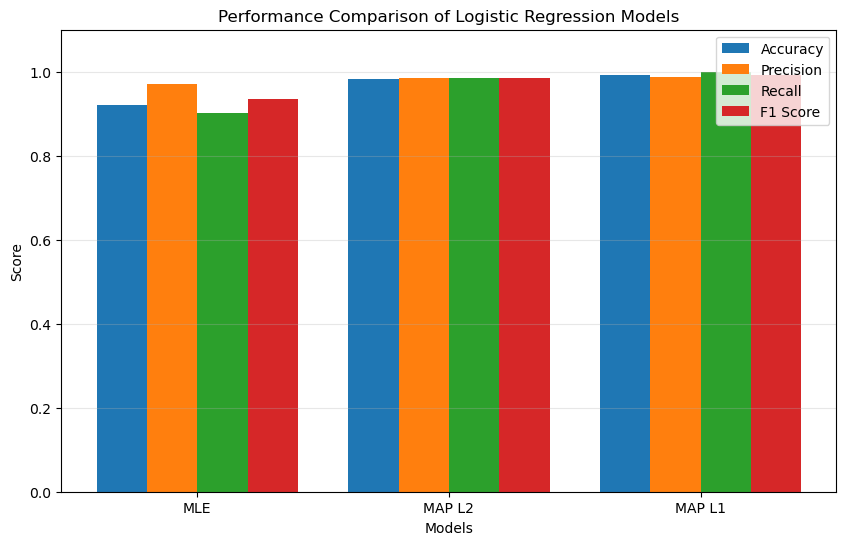

In [40]:

models = ["MLE", "MAP L2", "MAP L1"]

accuracy = [
    accuracy_score(Y_test, Y_pred_mle),
    accuracy_score(Y_test, Y_pred_l2),
    accuracy_score(Y_test, Y_pred_l1)
]

precision = [
    precision_score(Y_test, Y_pred_mle),
    precision_score(Y_test, Y_pred_l2),
    precision_score(Y_test, Y_pred_l1)
]

recall = [
    recall_score(Y_test, Y_pred_mle),
    recall_score(Y_test, Y_pred_l2),
    recall_score(Y_test, Y_pred_l1)
]

f1 = [
    f1_score(Y_test, Y_pred_mle),
    f1_score(Y_test, Y_pred_l2),
    f1_score(Y_test, Y_pred_l1)
]


x = np.arange(len(models))
width = 0.2


plt.figure(figsize=(10, 6))

plt.bar(x - 1.5 * width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5 * width, precision, width, label="Precision")
plt.bar(x + 0.5 * width, recall, width, label="Recall")
plt.bar(x + 1.5 * width, f1, width, label="F1 Score")


plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Performance Comparison of Logistic Regression Models")

plt.xticks(x, models)
plt.ylim(0, 1.1)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [35]:
print("Number of Zero Coefficents")
print ("MLE :",np.sum(mle_model.coef_[0]==0))
print ("MAP L2 :",np.sum(map_l2.coef_[0]==0))
print ("MAP L2 :",np.sum(map_l2.coef_[0]==0))

Number of Zero Coefficents
MLE : 0
MAP L2 : 0
MAP L2 : 14


In [38]:
results = pd.DataFrame(columns = [ "Model","Accuracy","Precision","Recall","F1 Score"])
models = [("MLE",mle_model,Y_pred_mle),("MAP L2",map_l2,Y_pred_l2),("MAP L1",map_l1,Y_pred_l1)]
for name, model, pred in models:
    results.loc[len(results)]=[name, accuracy_score(Y_test,pred),precision_score(Y_test,pred),recall_score(Y_test,pred),f1_score(Y_test,pred)]
print(results)

    Model  Accuracy  Precision    Recall  F1 Score
0     MLE  0.921053   0.970149  0.902778  0.935252
1  MAP L2  0.982456   0.986111  0.986111  0.986111
2  MAP L1  0.991228   0.986301  1.000000  0.993103


In [42]:
ax = result.set_index("Model").plot( kind ="bar",figsize=(10,6))
plt.title("Performance Comparison: MLE vs MAP-L2 vs MAP-l1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85,1.02)
plt.xticks(rotation=0)
plt.legend(title("Metric"))
plt.grid(axis="Y", alpha =0.3)

for container in ax.containers:
    ax.barr_label(container,fmt="%.3f",padding=2)
plt.tight_layout()
plt.show()

NameError: name 'result' is not defined